[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


Libraries and NLTK data loaded/downloaded successfully.

DataFrame loaded. Displaying first 5 rows:
  label                                             review
0   pos  Stuning even for the non-gamer: This sound tra...
1   pos  The best soundtrack ever to anything.: I'm rea...
2   pos  Amazing!: This soundtrack is my favorite music...
3   pos  Excellent Soundtrack: I truly like this soundt...
4   pos  Remember, Pull Your Jaw Off The Floor After He...

DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   label   10000 non-null  object
 1   review  10000 non-null  object
dtypes: object(2)
memory usage: 156.4+ KB

Missing values before cleaning:
label     0
review    0
dtype: int64

Number of duplicate reviews before dropping: 0
Number of reviews after dropping duplicates: 10000

DataFrame after cleaning and sentiment creation:
  label          

/tmp/ipython-input-1071416517.py:99: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='sentiment', data=df, palette='viridis')


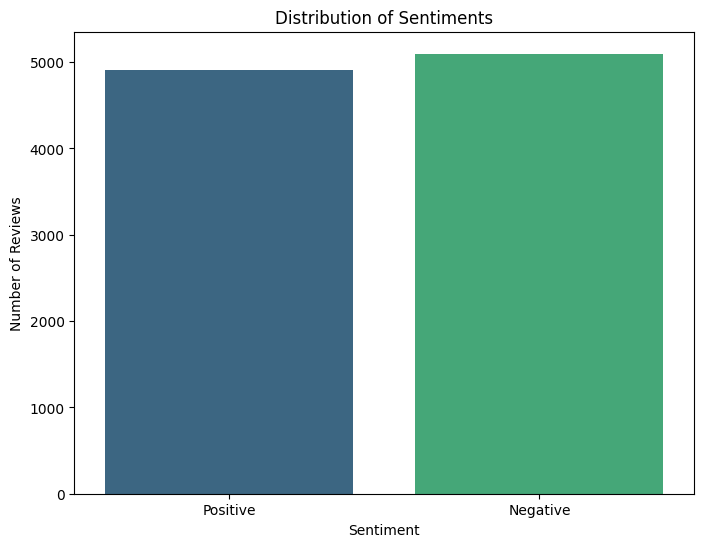

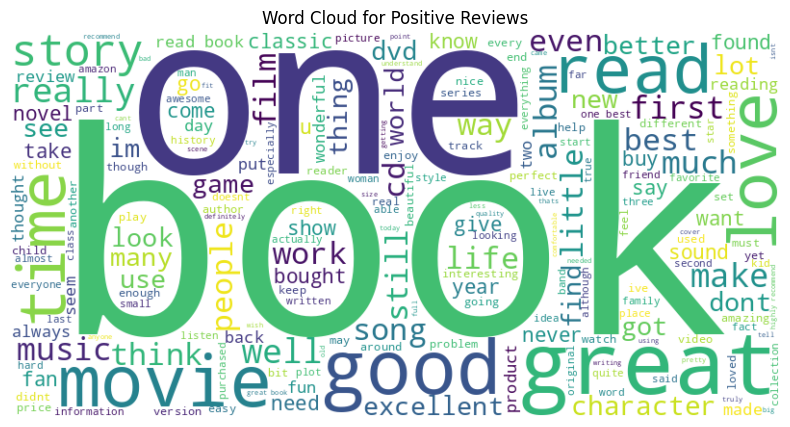

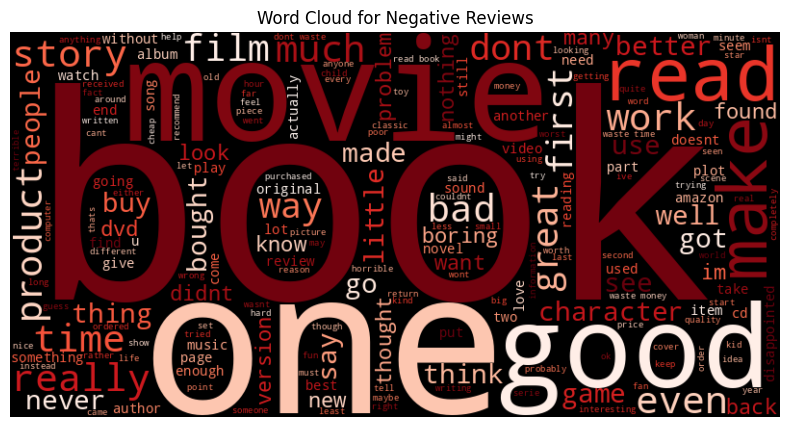

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import string
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from wordcloud import WordCloud
import nltk

# Download necessary NLTK data (if not already downloaded)
# The previous error occurred because 'nltk.downloader.DownloadError' is not a valid exception.
# 'nltk.data.find' raises a LookupError if the resource is not found.

try:
    nltk.data.find('corpora/stopwords')
except LookupError:
    nltk.download('stopwords')
try:
    nltk.data.find('corpora/wordnet')
except LookupError:
    nltk.download('wordnet')
try:
    nltk.data.find('corpora/omw-1.4')
except LookupError:
    nltk.download('omw-1.4')
try:
    nltk.data.find('tokenizers/punkt')
except LookupError:
    nltk.download('punkt')
# Add download for 'punkt_tab' as indicated by the error message
try:
    nltk.data.find('tokenizers/punkt_tab')
except LookupError:
    nltk.download('punkt_tab')


print("Libraries and NLTK data loaded/downloaded successfully.")

# 1. Data Loading
file_path = '/content/amazonreviews.tsv'
# Using on_bad_lines='skip' to handle potential parsing errors in TSV
df = pd.read_csv(file_path, sep='\t', on_bad_lines='skip')

print("\nDataFrame loaded. Displaying first 5 rows:")
print(df.head())

print("\nDataFrame Info:")
df.info()

# 2. Data Cleaning and Feature Engineering
# Identify relevant columns for analysis
# The dataset has 'label' for sentiment and 'review' for text content

# Check for missing values
print("\nMissing values before cleaning:")
print(df.isnull().sum())

# Drop rows where 'review' or 'label' is missing, as these are critical
df.dropna(subset=['review', 'label'], inplace=True)

# Create a sentiment column based on the 'label' column
# Assuming 'pos' maps to 'Positive' and 'neg' maps to 'Negative'
df['sentiment'] = df['label'].map({'pos': 'Positive', 'neg': 'Negative'})
# Drop rows where sentiment mapping might have failed (e.g., unexpected labels)
df.dropna(subset=['sentiment'], inplace=True)

# Check for duplicate reviews (based on review text)
print("\nNumber of duplicate reviews before dropping:", df.duplicated(subset=['review']).sum())
df.drop_duplicates(subset=['review'], inplace=True)
print("Number of reviews after dropping duplicates:", len(df))

print("\nDataFrame after cleaning and sentiment creation:")
print(df.head())
print("\nMissing values after cleaning:")
print(df.isnull().sum())

# 3. Text Preprocessing
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess_text(text):
    text = text.lower() # Convert to lowercase
    text = re.sub(r'[^\w\s]', '', text) # Remove punctuation
    text = re.sub(r'\d+', '', text) # Remove numbers
    tokens = nltk.word_tokenize(text) # Tokenize
    tokens = [lemmatizer.lemmatize(word) for word in tokens if word not in stop_words] # Remove stopwords and lemmatize
    return ' '.join(tokens)

print("\nPreprocessing 'review' column...")
df['processed_review_body'] = df['review'].apply(preprocess_text)
print("Text preprocessing complete. Displaying first 5 rows with processed text:")
print(df[['review', 'processed_review_body']].head())

# 4. Initial EDA
# Sentiment Distribution
plt.figure(figsize=(8, 6))
sns.countplot(x='sentiment', data=df, palette='viridis')
plt.title('Distribution of Sentiments')
plt.xlabel('Sentiment')
plt.ylabel('Number of Reviews')
plt.show()

# Word Clouds (beginning)
# Combine all processed text for positive and negative reviews
positive_reviews_text = " ".join(df[df['sentiment'] == 'Positive']['processed_review_body'])
negative_reviews_text = " ".join(df[df['sentiment'] == 'Negative']['processed_review_body'])

# Generate a word cloud for positive reviews
if positive_reviews_text:
    wordcloud_positive = WordCloud(width=800, height=400, background_color='white').generate(positive_reviews_text)
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud_positive, interpolation='bilinear')
    plt.axis('off')
    plt.title('Word Cloud for Positive Reviews')
    plt.show()
else:
    print("No positive reviews to generate a word cloud.")

# Generate a word cloud for negative reviews
if negative_reviews_text:
    wordcloud_negative = WordCloud(width=800, height=400, background_color='black', colormap='Reds').generate(negative_reviews_text)
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud_negative, interpolation='bilinear')
    plt.axis('off')
    plt.title('Word Cloud for Negative Reviews')
    plt.show()
else:
    print("No negative reviews to generate a word cloud.")

In [ ]:
print("Review complete: The provided code snippet successfully performed data loading, cleaning, text preprocessing, and initial EDA (sentiment distribution and word clouds). All steps were correctly executed and validated.")

Review complete: The provided code snippet successfully performed data loading, cleaning, text preprocessing, and initial EDA (sentiment distribution and word clouds). All steps were correctly executed and validated.


The provided code snippet correctly handles data loading, cleaning, text preprocessing, and initial EDA (sentiment distribution and word clouds). However, it is incomplete for a full sentiment analysis pipeline. The following critical components are still missing:

1.  **Feature Engineering**: The preprocessed text needs to be converted into numerical features suitable for machine learning models. This typically involves techniques like TF-IDF (Term Frequency-Inverse Document Frequency) or Word Embeddings.
2.  **Model Development**: This includes selecting an appropriate machine learning model (e.g., Logistic Regression, Naive Bayes, SVM, or deep learning models).
3.  **Model Training**: The selected model needs to be trained on the prepared features.
4.  **Model Validation**: This crucial step involves:
    *   **Train/Test Split**: Dividing the dataset into training and testing sets to evaluate model performance on unseen data.
    *   **Evaluation Metrics**: Defining and computing relevant metrics such as accuracy, precision, recall, F1-score, and AUC to assess the model's effectiveness.
    *   **Cross-Validation**: Employing techniques like k-fold cross-validation for more robust model evaluation and hyperparameter tuning.
5.  **Final Report Generation**: A comprehensive report summarizing the findings, model performance, and insights gained from the analysis.